In [7]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,SimpleRNN,Dropout

Building Simple RNN...
Training...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0119
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0047
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0046
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031
Epoch 5/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031
Epoch 6/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030
Epoch 7/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027
Epoch 8/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029
Epoch 9/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027
Epoch 10/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019
Epoch 11/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017
Epoch 12/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 13/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012    
Epoch 14/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018
Epoch 15/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0

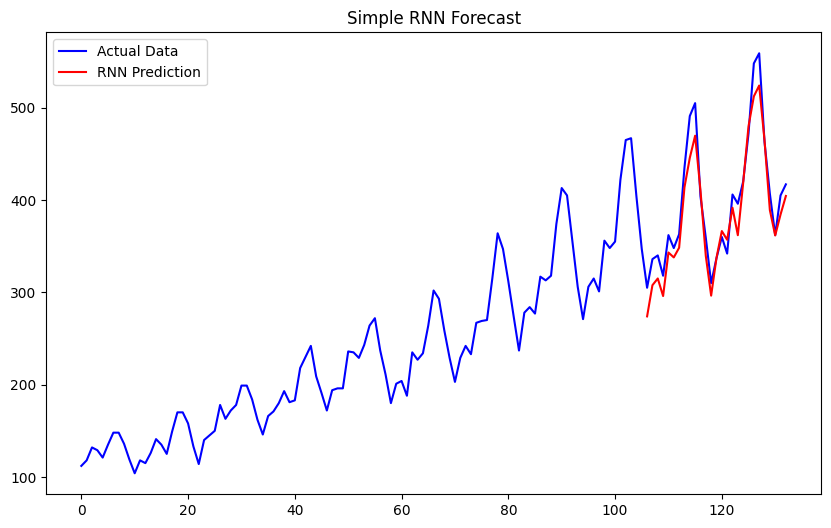

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

--- TEST SAMPLE #0 ---
Model Guessed: 273
Actual Number: 305
Off by:        31 passengers
Result: NEEDS IMPROVEMENT


In [8]:
class AirlineModel:
    def __init__(self,file_path,look_back=12,test_size = 0.3):
        self.file_path = file_path
        self.look_back = look_back
        self.scaler = MinMaxScaler(feature_range=(0,1))
        self.model = None

    def load_and_prepare(self):
        # Load and scale
        df = pd.read_csv(self.file_path,usecols=[1])
        data = self.scaler.fit_transform(df.values.astype('float32'))

        # Use Keras built-in helper to create windows (X and y)
        dataset = tf.keras.utils.timeseries_dataset_from_array(
        data, data, sequence_length=self.look_back, batch_size=len(data)
    )
       # Extract X and y from the helper
        for X, y in dataset:
            self.X, self.y = X.numpy(), y.numpy()
            break

        split = int(len(self.X) * 0.8)
        self.X_train, self.X_test = self.X[:split], self.X[split:]
        self.y_train, self.y_test = self.y[:split], self.y[split:]


    def build_and_train(self, epochs=20):
        print("Building Simple RNN...")
        self.model = Sequential([
            # Using SimpleRNN
            SimpleRNN(64, input_shape=(self.look_back, 1), activation='relu'),
            Dense(1)
        ])
        self.model.compile(optimizer='adam', loss='mean_squared_error')
        print("Training...")
        self.model.fit(self.X_train,
                       self.y_train,
                       epochs=epochs,
                       batch_size=1,
                       verbose=1)

    def evaluate(self):
        print("Predicting...")
        train_pred = self.model.predict(self.X_train)
        test_pred = self.model.predict(self.X_test)

        #Convert back to original scale (e.g., 0.5 -> 500 passengers)
        test_pred = self.scaler.inverse_transform(test_pred)
        actual_y = self.scaler.inverse_transform(self.y.reshape(-1, 1))

        #Plotting
        plt.figure(figsize=(10, 6))

        #Plot the full real data line
        plt.plot(actual_y, label="Actual Data", color="blue")

        #Plot predictions starting exactly where the test data begins
        test_start_index = len(train_pred)
        plt.plot(range(test_start_index, len(actual_y)), test_pred,
                label="RNN Prediction", color="red")
        plt.title("Simple RNN Forecast")
        plt.legend()
        plt.show()


    def rnn_prediction_demo(self, idx=0): # Added self, removed other args
        # 1. Take a single sequence from your test set
         guess_scaled = self.model.predict(self.X_test[idx:idx+1]) # (1, look_back, 1)

    # 2. Convert both back to real numbers
         guess = self.scaler.inverse_transform(guess_scaled)[0][0]
         real = self.scaler.inverse_transform(self.y_test[idx].reshape(-1, 1))[0][0]

          # 3. Calculate the gap (Error)
         diff = abs(guess - real)

          # 4. Show the results simply
         print(f"\n--- TEST SAMPLE #{idx} ---")
         print(f"Model Guessed: {int(guess)}")
         print(f"Actual Number: {int(real)}")
         print(f"Off by:        {int(diff)} passengers")

          # 5. Quick Rating
         status = "EXCELLENT" if diff < 15 else "NEEDS IMPROVEMENT"
         print(f"Result: {status}")


# Execution
DATA_URL = 'airline-passengers.csv'
rnn_project = AirlineModel(DATA_URL)
rnn_project.load_and_prepare()
rnn_project.build_and_train(epochs=50)
rnn_project.evaluate()
rnn_project.rnn_prediction_demo()

